# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

importar y leer cada archivo  para porder limpiar y procesar los datos. 

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# leer conjuntos de datos en los DataFrames
orders = pd.read_csv('/datasets/instacart_orders.csv',sep=';')
products = pd.read_csv('/datasets/products.csv',sep=';')
aisles = pd.read_csv('/datasets/aisles.csv',sep=';')
departments = pd.read_csv('/datasets/departments.csv',sep=';')
order_products = pd.read_csv('/datasets/order_products.csv',sep=';')

In [3]:
# mostrar información del DataFrame
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
# mostrar información del DataFrame
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
# mostrar información del DataFrame
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [6]:
# mostrar información del DataFrame
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [7]:
# mostrar información del DataFrame
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

en cada archivo hay valores nulos y duplicados


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

verificar y eliminar datos duplicatos y ausentes usandato los metodos correspondientes

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

no, no hay duplicados

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.

orders[(orders['order_dow']==3)& (orders['order_hour_of_day']==2)]




,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


¿Qué sugiere este resultado?

que se hicieron 121 ordenes el miercoles a las 2 AM.

In [10]:
# Elimina los pedidos duplicados
orders= orders.drop_duplicates()



In [11]:
# Vuelve a verificar si hay filas duplicadas
orders[orders.duplicated()]


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
orders[orders.duplicated(subset='order_id')]



,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Describe brevemente tus hallazgos y lo que hiciste con ellos

se verifo si habian datos duplicados usando el metodo duplicated() y se eliminaron los datos duplicatos con el metodo drop_duplicates() depues de eliminar los duplicados se volvio a verificar nuevamente si habian pedidos duplicados con el metodo  duplicated().

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
products[products.duplicated()]

,product_id,product_name,aisle_id,department_id


In [14]:
# Revisa únicamente si hay ID de productos duplicados
products[products.duplicated(subset='product_id')]


,product_id,product_name,aisle_id,department_id


In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products[products['product_name'].str.upper().duplicated()]

,product_id,product_name,aisle_id,department_id
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
436,437,NaN,100,21
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


In [16]:
# Revisa si hay nombres duplicados de productos no faltantes

products[(products['product_name'].str.upper().duplicated()) & (products['product_name'].notna())]


,product_id,product_name,aisle_id,department_id
2058,2059,Biotin 1000 Mcg,47,11
5455,5456,Green Tea With Ginseng and Honey,96,20
5558,5559,Cream Of Mushroom Soup,69,15
7558,7559,Cinnamon Rolls with Icing,105,13
9037,9038,American Cheese slices,21,16
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


Describe brevemente tus hallazgos y lo que hiciste con ellos.

usando el metodo duplicated() she verifico si habia filas duplicadas, usando el metodo upper() se cambiaron los nombres a mayusculas y usando el metodo duplicated() se reviso si habian nombre de productos duplicados.

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
departments[departments.duplicated()]


,department_id,department


In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
departments[departments['department_id'].duplicated()]


,department_id,department


Describe brevemente tus hallazgos y lo que hiciste con ellos.

despues de usar el metodo duplicated() para revisar si hay datos duplicados las filas no arrojaron ninguna info por lo cual se puede determinar que no hay  filas duplicadas.

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
aisles[aisles.duplicated()]


,aisle_id,aisle


In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
aisles[aisles['aisle_id'].duplicated()]


,aisle_id,aisle


Describe brevemente tus hallazgos y lo que hiciste con ellos.

al igual que departments data frame, despues de usar el metodo duplicated() para revisar si hay datos duplicados las filas no arrojaron ninguna info por lo cual se puede determinar que no hay  filas duplicadas. 


### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
order_products[order_products.duplicated()]


,order_id,product_id,add_to_cart_order,reordered


In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
order_products[order_products.duplicated()]


,order_id,product_id,add_to_cart_order,reordered


Describe brevemente tus hallazgos y lo que hiciste con ellos.

no hay filas duplicadas

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [24]:
# Encuentra los valores ausentes en la columna 'product_name'
products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos.

hay datos nulos en la columna Product_name y al paracer estan relacionados con el pasillo 100 y departamento 21

In [25]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
products[(products['aisle_id']==100) & (products['product_name'].isna())]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos.

Si, los  nombre de productos ausentes estan relacionados con el pasillo ID 100 ya que al filtrar  los datos dan el mismo total de 1258.

In [26]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
products[(products['product_name'].isna()) & (products['department_id']==21)]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos.

Si, todos los nombres de productos ausentes  estan relacionados con el departamendo 21 ya que el total es el mismo 1258 al filtrar los datos

In [27]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
products[(products['aisle_id']==100) & (products['department_id']==21)]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos.

los nombre ausentes estan relacionados con el pasillo 100 y departamento 21

In [28]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('unknown')

In [29]:
products[(products['aisle_id']==100) & (products['department_id']==21)]

,product_id,product_name,aisle_id,department_id
37,38,unknown,100,21
71,72,unknown,100,21
109,110,unknown,100,21
296,297,unknown,100,21
416,417,unknown,100,21
...,...,...,...,...
49552,49553,unknown,100,21
49574,49575,unknown,100,21
49640,49641,unknown,100,21
49663,49664,unknown,100,21


Describe brevemente tus hallazgos y lo que hiciste con ellos.

usando el metodo isna() se encontro los valores ausentes en la columna product_name despues de filtrar se pudo determinar que los productos  con nombres  ausentes estaban relacionados con el departament 21 y el pasillo 100 finalmente se reeplazo los nombres ausentes por unknown con el metodo fillna().

### `orders` data frame

In [30]:
# Encuentra los valores ausentes
orders[orders['days_since_prior_order'].isna()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [31]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
orders[(orders['days_since_prior_order'].isna()) & (orders['order_number']!=1)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Describe brevemente tus hallazgos y lo que hiciste con ellos.
despues de filtrar  se puede observar que el unico valor ausente esta en el primer pedido del cliente. 

### `order_products` data frame

In [32]:
# Encuentra los valores ausentes
order_products[order_products['add_to_cart_order'].isna()]
order_products_clean= order_products[~order_products['add_to_cart_order'].isna()]


In [33]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
order_products_clean['add_to_cart_order'].astype(int).min()


1

In [34]:
order_products_clean['add_to_cart_order'].astype(int).max()

64

Describe brevemente cuáles son tus hallazgos.

despues de fitrar el valor minimo  de la columna add_to_cart_order es 1 y el maximo es 64

In [35]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

orders_filtered= order_products[order_products['add_to_cart_order'].isna()]
orders_filtered.head()




,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1


In [36]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

orders_filtered.groupby('order_id')['product_id'].count()


order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Name: product_id, Length: 70, dtype: int64

In [37]:
orders_filtered.groupby('order_id')['product_id'].count().min()

1

In [38]:
orders_filtered.groupby('order_id')['product_id'].count().max()

63

In [39]:
# Código del revisor
order_products[order_products['order_id'].isin(orders_filtered['order_id'])].groupby('order_id')['product_id'].count().min()

65

Describe brevemente cuáles son tus hallazgos.

despues de agrupar todos los pedidos con datos ausentes por su ID de pedido no todos los pedidos con valores ausentes tienen más de 64 productos.

In [40]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna('999').astype(int) 

order_products['add_to_cart_order'].isnull().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.

despues de reemplazar los valores ausentes con 999 y convertir la columna a tipo entero el valor devuelto es cero lo que significa que se hicieron los cambios. 

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

en cada uno de la data frames de verifico si habian datos ausentes y duplicatos usando el metodo duplicated() e isna() se eliminaron los duplicados con el metodo drop_duplicated() y se reemplazaron los valores ausentes con el metodo fillna()


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [41]:
dow = orders['order_dow'].unique()
dow.sort()
print(dow)

[0 1 2 3 4 5 6]


In [42]:
ohd = orders['order_hour_of_day'].unique()
ohd.sort()
print (ohd)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


Escribe aquí tus conclusiones

todos los valores son sensibles cumplen con el parametreo 0-6 en el caso de 'order_dow' y  0-23 'order_hour_of_day'.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

In [43]:
orders.groupby('order_hour_of_day')['order_id'].count()

order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_id, dtype: int64

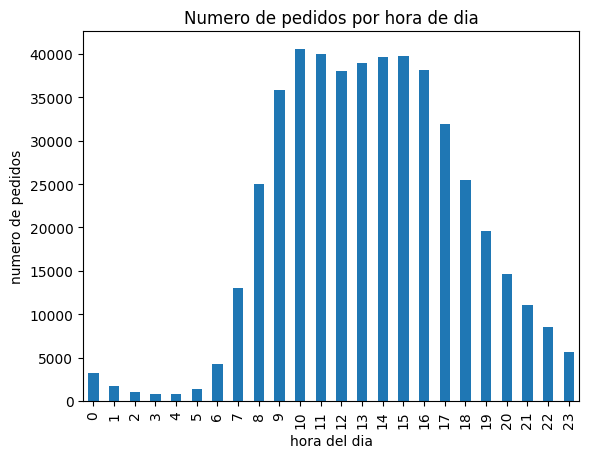

In [44]:
orders_by_hour = orders.groupby('order_hour_of_day')['order_id'].count()

orders_by_hour.plot( kind ='bar',
                 title='Numero de pedidos por hora de dia',
                 xlabel='hora del dia',
                 ylabel='numero de pedidos')
plt.show()


Escribe aquí tus conclusiones

### [A3] ¿Qué día de la semana compran víveres las personas?

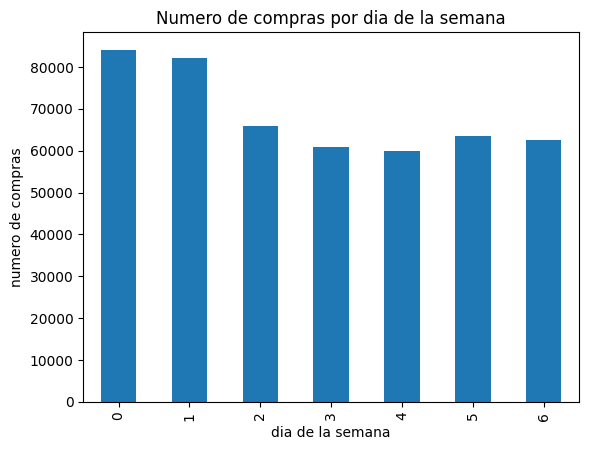

In [45]:
orders_by_day = orders.groupby('order_dow')['order_id'].count()

orders_by_day.plot( kind ='bar',
                    title='Numero de compras por dia de la semana',
                    xlabel='dia de la semana',
                    ylabel='numero de compras')

plt.show()


Escribe aquí tus conclusiones

los dias  que mas compran viveres son los domingos y lunes.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

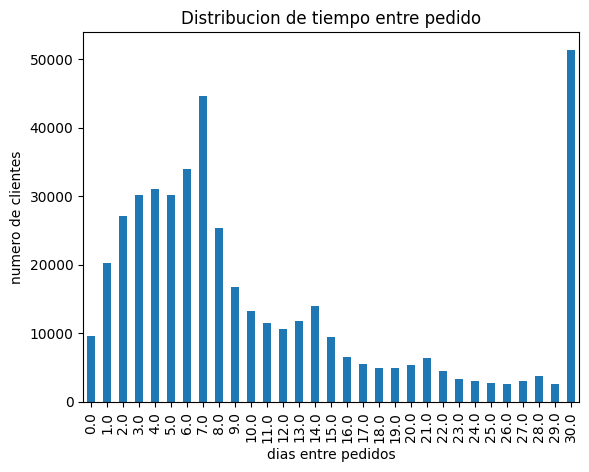

In [46]:
orders_by_time = orders.groupby('days_since_prior_order')['order_id'].count()

orders_by_time.plot( kind ='bar',
                    title='Distribucion de tiempo entre pedido',
                    xlabel='dias entre pedidos',
                    ylabel='numero de clientes')
plt.show()



Escribe aquí tus conclusiones

los dias de mayor pico son los dias 30 y 7 del mes, se puede decir que en promedio  las personas hacen pedido cada 30 dias.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [47]:
miercoles = orders[orders['order_dow']==3] 
horas_miercoles = miercoles.groupby('order_hour_of_day')['order_id'].count()

sabado = orders[orders['order_dow']==6] 
horas_sabado = sabado.groupby('order_hour_of_day')['order_id'].count()

dias_filtrados = pd.concat([horas_miercoles, horas_sabado],axis=1)

dias_filtrados.columns= ['miercoles','sabado']

dias_filtrados



,miercoles,sabado
order_hour_of_day,,
0,373,464
1,215,254
2,106,177
3,101,125
4,108,118
5,170,161
6,643,451
7,1732,1619
8,3125,3246


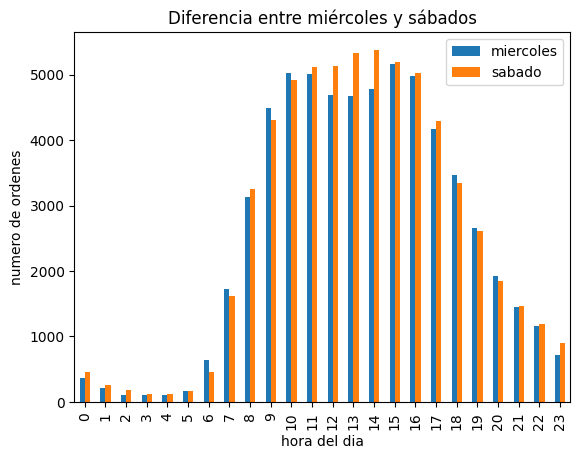

In [48]:

dias_filtrados.plot( kind ='bar',
                    title='Diferencia entre miércoles y sábados',
                    xlabel='hora del dia',
                    ylabel='numero de ordenes')
plt.show()




Escribe aquí tus conclusiones

los dias sabados she hacen mas ordenes que el miercoles. Tambien se puede observar que las horas pico de compras es de 9am a 4PM. 

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

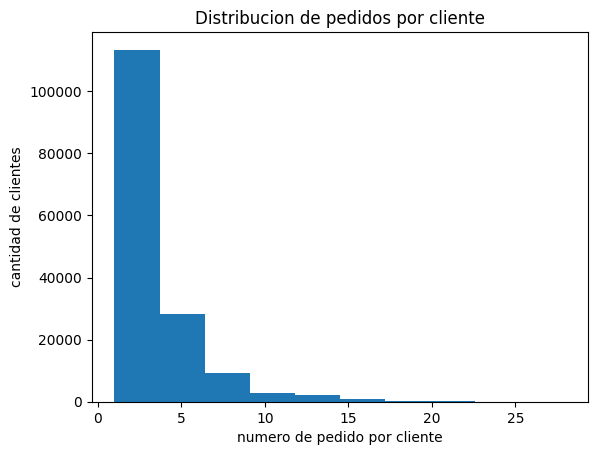

In [49]:
orders_per_customer = orders.groupby('user_id')['order_id'].count()

orders_per_customer.plot( kind ='hist', title='Distribucion de pedidos por cliente')
plt.xlabel('numero de pedido por cliente')
plt.ylabel('cantidad de clientes')
plt.show()




Escribe aquí tus conclusiones

se puede observar que los clientes hacen entre 1 a 20 pedidos. 

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [50]:
df_combined = order_products.merge(products,on='product_id')
top_20_products = df_combined.groupby(['product_id','product_name'])['order_id'].count().sort_values(ascending=False).head(20)
top_20_products



product_id  product_name            
24852       Banana                      66050
13176       Bag of Organic Bananas      53297
21137       Organic Strawberries        37039
21903       Organic Baby Spinach        33971
47209       Organic Hass Avocado        29773
47766       Organic Avocado             24689
47626       Large Lemon                 21495
16797       Strawberries                20018
26209       Limes                       19690
27845       Organic Whole Milk          19600
27966       Organic Raspberries         19197
22935       Organic Yellow Onion        15898
24964       Organic Garlic              15292
45007       Organic Zucchini            14584
39275       Organic Blueberries         13879
49683       Cucumber Kirby              13675
28204       Organic Fuji Apple          12544
5876        Organic Lemon               12232
8277        Apple Honeycrisp Organic    11993
40706       Organic Grape Tomatoes      11781
Name: order_id, dtype: int64

<AxesSubplot:xlabel='product_id,product_name'>

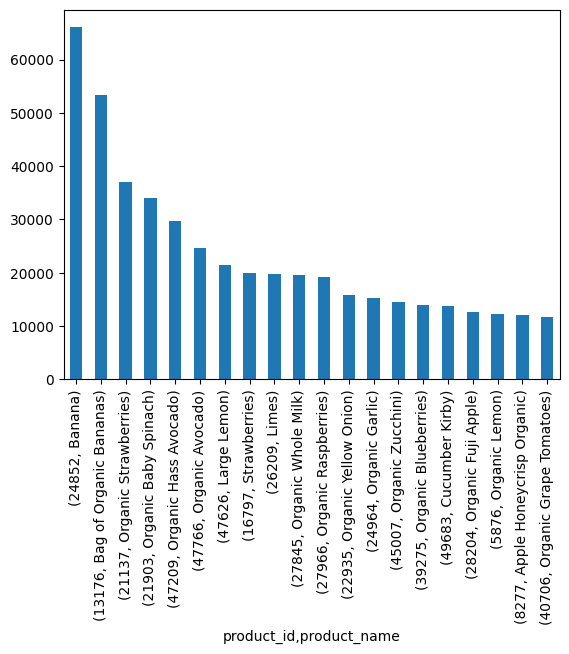

In [51]:
top_20_products.plot.bar()

Escribe aquí tus conclusiones

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [52]:
total_articulos = order_products.groupby('order_id')['product_id'].count().reset_index()
display(total_articulos)
  

,order_id,product_id
0,4,13
1,9,15
2,11,5
3,19,3
4,20,8
...,...,...
450041,3421034,17
450042,3421053,9
450043,3421071,5
450044,3421077,4


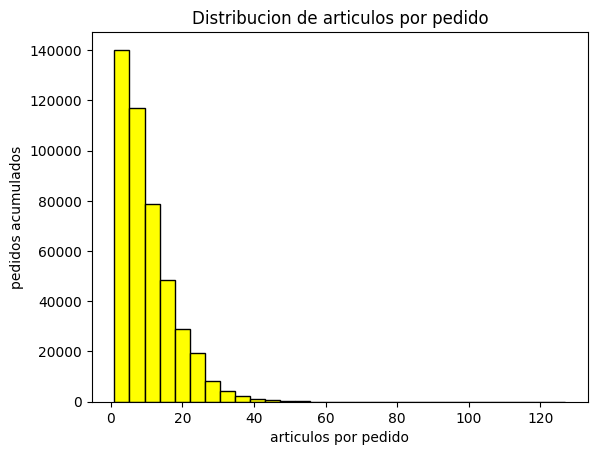

In [53]:
plt.hist(total_articulos['product_id'],bins=30,edgecolor='k',color='yellow')

plt.title('Distribucion de articulos por pedido')
plt.ylabel('pedidos acumulados')
plt.xlabel('articulos por pedido')
plt.show()



Escribe aquí tus conclusiones

las personas compran entre 1 a 17 articulos.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [54]:
reordered_products = order_products[order_products['reordered']==1]
df_combinado = reordered_products.merge(products,on='product_id')
df_combinado.groupby(['product_id','product_name'])['order_id'].count().sort_values(ascending=False).head(20)

product_id  product_name            
24852       Banana                      55763
13176       Bag of Organic Bananas      44450
21137       Organic Strawberries        28639
21903       Organic Baby Spinach        26233
47209       Organic Hass Avocado        23629
47766       Organic Avocado             18743
27845       Organic Whole Milk          16251
47626       Large Lemon                 15044
27966       Organic Raspberries         14748
16797       Strawberries                13945
26209       Limes                       13327
22935       Organic Yellow Onion        11145
24964       Organic Garlic              10411
45007       Organic Zucchini            10076
49683       Cucumber Kirby               9538
28204       Organic Fuji Apple           8989
8277        Apple Honeycrisp Organic     8836
39275       Organic Blueberries          8799
5876        Organic Lemon                8412
49235       Organic Half & Half          8389
Name: order_id, dtype: int64

Escribe aquí tus conclusiones

combinando las columnas con el metodo merge() y usando el metodo head(), se pudo obtener los productos y nombre de productos que mas se venden. 

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [55]:

products_merge = products.merge(order_products,on ='product_id')
products_merge.head()

,product_id,product_name,aisle_id,department_id,order_id,add_to_cart_order,reordered
0,1,Chocolate Sandwich Cookies,61,19,1104373,11,1
1,1,Chocolate Sandwich Cookies,61,19,1774977,4,1
2,1,Chocolate Sandwich Cookies,61,19,652770,10,0
3,1,Chocolate Sandwich Cookies,61,19,1000035,6,1
4,1,Chocolate Sandwich Cookies,61,19,1679949,9,0


In [56]:
productos_filtrados = products_merge.groupby(['product_id','product_name'])['reordered']

productos_filtrados_rate = productos_filtrados.sum()/productos_filtrados.count()

print(productos_filtrados_rate)
    

product_id  product_name                                                     
1           Chocolate Sandwich Cookies                                           0.564286
2           All-Seasons Salt                                                     0.000000
3           Robust Golden Unsweetened Oolong Tea                                 0.738095
4           Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce    0.510204
7           Pure Coconut Water With Orange                                       0.500000
                                                                                   ...   
49690       HIGH PERFORMANCE ENERGY DRINK                                        0.800000
49691       ORIGINAL PANCAKE & WAFFLE MIX                                        0.430556
49692       ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR                      0.416667
49693       SPRING WATER BODY WASH                                               0.440000
49694       BURRITO- S

Escribe aquí tus conclusiones

en promedio se vuelven a pedir los mismos productos entre un 50% a 80%

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [57]:
client_merge = orders.merge(order_products,on ='order_id')   

client_merge.head()


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,1515936,183418,11,6,13,30.0,19048,1,1
1,1515936,183418,11,6,13,30.0,47766,3,1
2,1515936,183418,11,6,13,30.0,45066,9,0
3,1515936,183418,11,6,13,30.0,24082,11,0
4,1515936,183418,11,6,13,30.0,24363,4,0


In [58]:

total_products = client_merge.groupby('user_id')['reordered'].count()

reordered_products = client_merge[client_merge['reordered'] == 1].groupby('user_id')['product_id'].count()

reordered_products.head()

reordered_products / total_products



user_id
2         0.038462
4              NaN
5         0.666667
6              NaN
7         0.928571
            ...   
206203    0.222222
206206    0.714286
206207    0.891304
206208    0.696000
206209    0.320000
Length: 149626, dtype: float64

Escribe aquí tus conclusiones

la proporcion de los productos que ya se habian pedido es de un 30%

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [59]:
top_20_products = order_products[order_products['add_to_cart_order']==1]

top_20_products.groupby(['product_id'])['reordered'].count().sort_values(ascending=False).head(20)

product_id
24852    15562
13176    11026
27845     4363
21137     3946
47209     3390
21903     3336
47766     3044
19660     2336
16797     2308
27966     2024
44632     1914
49235     1797
47626     1737
196       1733
38689     1397
26209     1370
12341     1340
5785      1310
27086     1309
43352     1246
Name: reordered, dtype: int64

Escribe aquí tus conclusiones

filtrando por la fila de  'product_id' y'reordered' y usando el metodo head() se pudo obtener los 20 productos principales en los carritos de los usuarios. 


### Conclusion general del proyecto:

In [ ]:
al llamar mis 5 data frames, podemos observar que hay filas duplicadas, valores ausentes y columnas en minisculas
por lo tanto para corregir estos errores se utilizo el  metodo duplicated() para revisar las filas duplicadas
y drop_duplicated() para eliminarlas, tambien se reviso si habian valores ausentes con el metodo isna() y se
reemplazaronestos valores son el metodo fillna() de igual manera los  las columnas que estaban en minisculas se
cambiaron a mayusculascon el metodo upper().

para la segunda parte del proyecto de utilizo el metodo groupby() para agrupar las columnas necesarias para sacar
el comporamiento de compras de los usuarios para despues motraslos los distintos tipos de grafica en barras 
e histogramas con el metodo plot().
    

